In [2]:
from AgentBasedModel import *
from AgentBasedModel.params_calibration.utils_calibration import *
from AgentBasedModel.params_calibration.calibrationv2.utils_calibration_v2 import *
import random
import numpy as np
import optuna

In [3]:
# всякие константы для обучения
N_RUNS = 4
N_TICKS = 1000
CASH = 10 ** 4
EXCHANGE_VOLUME = 1000

target_params = pd.read_csv('mean_std_ethusdt_validation_data2.csv')
NORM_COEF_LR = 1 / target_params.loc[target_params["param"] == 'mean_on_ret2', "mean"].iloc[0]

In [4]:
# метрика лосса: mse где нормировка по корню дисперсии: самое научное, что я придумал/нашел
# + байесовское обучение оптуной, все диапазоны я выбрал интуитивно руководствуясь логикой/статьями
def loss_mse(t_params, m_params):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret"]
    arrs = ["autocorrelation_on_ret", "autocorrelation_on_abs_ret"]
    error = 0
    for i in arrs:
        m_params[i] = m_params[i].mean()
    for i in num + arrs:
        error += ((t_params.loc[t_params["param"] == i, "mean"].iloc[0] - m_params[i]) / t_params.loc[t_params["param"] == i, "std"].iloc[0]) ** 2
    return error / len(num + arrs)

def objective(trial):
    params = {
        'Random': trial.suggest_int('Random', 5, 100),
        'Fundamentalist': trial.suggest_int('Fundamentalist', 5, 100),
        'Chartist': trial.suggest_int('Chartist', 5, 100),
        'Universalist': trial.suggest_int('Universalist', 5, 100),
        'MarketMaker': trial.suggest_int('MarketMaker', 0, 1),
        'Transaction_cost': trial.suggest_float("Transaction_cost", 1e-4, 1e-1, log=True),
        'Std':  trial.suggest_float("Std", 1e-1, 1e2, log=True),
        'Std_Random':  trial.suggest_float("Std_Random", 1e-2, 1e1, log=True),
        'Avg_Traders': trial.suggest_float("Avg_Traders", -5, 0),
        'Last_Step': trial.suggest_float("Last_Step", 0, 1),
        'Last_Ret': trial.suggest_float("Last_Ret", 1e-3, 50, log=True),
        'Noisy_Level': trial.suggest_float("Noisy_Level", 1e-3, 5, log=True)
    }
    errors = []

    for run_idx in range(N_RUNS):
        random.seed(42 + run_idx)
        np.random.seed(42 + run_idx)

        try:
            exchange = ExchangeAgent(volume=CASH, std=params['Std'], transaction_cost=params['Transaction_cost'], std_random=params['Std_Random'], divs_drifted=True)
            simulator2 = Simulator(**{
                'exchange': exchange,
                'traders': [
                    *[Random(exchange, CASH) for _ in range(params['Random'])],
                    *[Fundamentalist(exchange, CASH) for _ in range(params['Fundamentalist'])],
                    *[Chartist(exchange, CASH) for _ in range(params['Chartist'])],
                    *[Universalist(exchange, CASH) for _ in range(params['Universalist'])],
                    *[MarketMaker(exchange, CASH) for _ in range(params['MarketMaker'])],
                ],
            }, avg_traders=params['Avg_Traders'], last_step=params['Last_Step'], last_ret=params['Last_Ret'], noisy_level=params['Noisy_Level'], norm_coef_lr=NORM_COEF_LR)

            simulator2.simulate(N_TICKS, silent=True)
            prices = np.array(simulator2.info.prices)
            model_params = pipeline(prices, is_print=0)
            errors.append(loss_mse(target_params, model_params))
        except Exception:
            continue

    if len(errors) != N_RUNS:
        return 100000
    return float(np.mean(errors))

In [ ]:
# само обучение
study_mse = optuna.create_study(study_name="calibration_mse_2(10000)", direction="minimize", storage="sqlite:///calibration_mse_2(10000)",  load_if_exists=True)
study_mse.optimize(objective, show_progress_bar=True, n_trials=500)

best_params = study_mse.best_params
best_score = study_mse.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

[I 2026-03-29 22:45:54,961] A new study created in RDB with name: calibration_mse_2(10000)
Best trial: 0. Best value: 29.9915:   0%|          | 1/500 [00:32<4:28:03, 32.23s/it]

[I 2026-03-29 22:46:27,191] Trial 0 finished with value: 29.991467856145526 and parameters: {'Random': 73, 'Fundamentalist': 25, 'Chartist': 57, 'Universalist': 93, 'MarketMaker': 0, 'Transaction_cost': 0.0006648341233672868, 'Std': 0.9922446378180564, 'Std_Random': 1.6567604268664664, 'Avg_Traders': -2.04058651681311, 'Last_Step': 0.020730777581118187, 'Last_Ret': 0.017949102838907854, 'Noisy_Level': 0.2985376328179023}. Best is trial 0 with value: 29.991467856145526.


Best trial: 0. Best value: 29.9915:   0%|          | 2/500 [01:12<5:05:39, 36.83s/it]

[I 2026-03-29 22:47:07,236] Trial 1 finished with value: 238.2047576313924 and parameters: {'Random': 74, 'Fundamentalist': 96, 'Chartist': 14, 'Universalist': 97, 'MarketMaker': 1, 'Transaction_cost': 0.00047798883124948845, 'Std': 61.10886144948753, 'Std_Random': 0.5226044871544514, 'Avg_Traders': -2.1414157114131798, 'Last_Step': 0.7707718268148235, 'Last_Ret': 15.432224371014069, 'Noisy_Level': 0.27340282571273694}. Best is trial 0 with value: 29.991467856145526.


Best trial: 0. Best value: 29.9915:   1%|          | 3/500 [01:50<5:12:00, 37.67s/it]

...

Best trial: 24. Best value: 0.674504:  15%|█▍        | 74/500 [38:08<3:49:53, 32.38s/it]

[I 2026-03-29 23:24:03,495] Trial 73 finished with value: 0.9052044968922843 and parameters: {'Random': 78, 'Fundamentalist': 41, 'Chartist': 16, 'Universalist': 35, 'MarketMaker': 1, 'Transaction_cost': 0.0015904819369798907, 'Std': 0.6990322689229567, 'Std_Random': 0.438660640878232, 'Avg_Traders': -2.0494549507164406, 'Last_Step': 0.3118437528477939, 'Last_Ret': 0.12627420022273425, 'Noisy_Level': 0.0096093312531406}. Best is trial 24 with value: 0.6745043404053339.


Best trial: 24. Best value: 0.674504:  15%|█▌        | 75/500 [38:43<3:54:22, 33.09s/it]

[I 2026-03-29 23:24:38,244] Trial 74 finished with value: 1.3037271145052958 and parameters: {'Random': 76, 'Fundamentalist': 23, 'Chartist': 12, 'Universalist': 35, 'MarketMaker': 1, 'Transaction_cost': 0.003054817383161122, 'Std': 0.47224762245326446, 'Std_Random': 0.24244306337353616, 'Avg_Traders': -1.9465358465284834, 'Last_Step': 0.46173370084628146, 'Last_Ret': 0.22749275734872676, 'Noisy_Level': 0.009450457555038741}. Best is trial 24 with value: 0.6745043404053339.


Best trial: 24. Best value: 0.674504:  15%|█▌        | 75/500 [39:16<3:54:22, 33.09s/it]

[I 2026-03-30 11:25:26,643] Using an existing study with name 'calibration_mse_2(10000)' instead of creating a new one.
C:\Users\rodion\AppData\Local\Temp\ipykernel_22500\2109210197.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_mse)


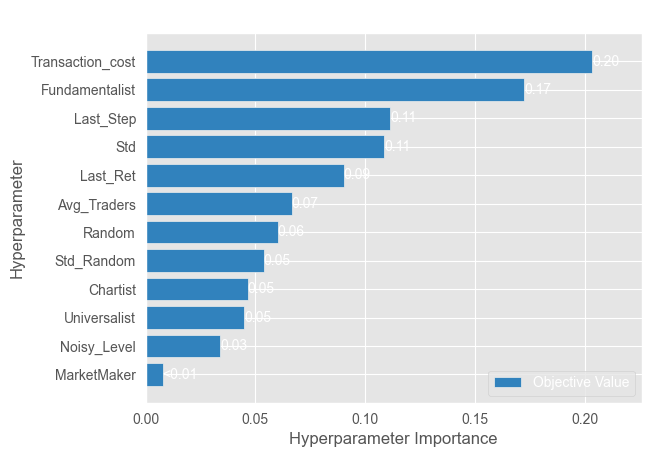

In [3]:
from optuna.visualization.matplotlib import plot_param_importances
import sklearn

study_mse = optuna.create_study(study_name="calibration_mse_2(10000)", direction="minimize", storage="sqlite:///calibration_mse_2(10000)",  load_if_exists=True)
plot_param_importances(study_mse)
plt.show()

In [4]:
best_params = study_mse.best_params
best_score = study_mse.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

Best params: {'Random': 86, 'Fundamentalist': 10, 'Chartist': 93, 'Universalist': 25, 'MarketMaker': 0, 'Transaction_cost': 0.003095907665014662, 'Std': 1.7423896293875045, 'Std_Random': 0.8495817651006533, 'Avg_Traders': -2.6870636551318805, 'Last_Step': 0.9322685735761159, 'Last_Ret': 0.0021349568484488896, 'Noisy_Level': 0.014459965033339264}
Best Score: 0.21038277195773414
